Objective:

The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.

Datasets :

Data Preprocessing:

1. Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

2. Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

3. Use multiple visualizations to understand the hidden patterns in the dataset

Implementing Clustering Algorithms:

· Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

· Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

· Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.


Cluster Analysis and Interpretation:

· Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.
Visualization:

Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

Evaluation and Performance Metrics:

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [3]:
# Load Dataset
df = pd.read_excel("EastWestAirlines.xlsx")
df

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
5,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID


In [4]:
df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [5]:
df.tail()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
21,Bonus_trans,NUMBER,NaN,Raw,Number of non-flight bonus transactions in the...
22,Flight_miles_12mo,NUMBER,NaN,Raw,Number of flight miles in the past 12 months
23,Flight_trans_12,NUMBER,NaN,Raw,Number of flight transactions in the past 12 m...
24,Days_since_enroll,NUMBER,NaN,Telcom,Number of days since Enroll_date
25,Award?,NUMBER,NaN,Telcom,"Dummy variable for Last_award (1=not null, 0=n..."


In [6]:
# Information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  18 non-null     object
 1   Unnamed: 1                                                                             13 non-null     object
 2   Unnamed: 2                                                                             6 non-null      object
 3   Unnamed: 3                                                                             13 non-null     object
 4   Unnamed: 4                                                                             18 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [7]:
# Shape of the data
df.shape

(26, 5)

## Data Preprocessing

In [8]:
# Chexking missing values
df.isnull().sum()

East-West Airlines is trying to learn more about its customers.  Key issues are their     8
Unnamed: 1                                                                               13
Unnamed: 2                                                                               20
Unnamed: 3                                                                               13
Unnamed: 4                                                                                8
dtype: int64

In [9]:
# Checking duplicated values
df.duplicated()

0     False
1     False
2     False
3      True
4     False
5     False
6      True
7      True
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
dtype: bool

In [11]:
# Dropping customer id
df.drop(columns=['ID#'], errors='ignore', inplace=True)

In [12]:
print(df.columns.tolist())

['East-West Airlines is trying to learn more about its customers.  Key issues are their', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [13]:
# Statistical summary
df.describe()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,18,13,6,13,18
unique,18,3,3,3,18
top,"flying patterns, earning and use of frequent f...",NUMBER,1,Raw,Description
freq,1,9,3,9,1


#### Observation

* Balance and Bonus Miles have large variations.
* Some features contain extreme values (outliers).
* Scaling is required before clustering.

# EDA

In [16]:
# Histogram
df.dtypes

East-West Airlines is trying to learn more about its customers.  Key issues are their    object
Unnamed: 1                                                                               object
Unnamed: 2                                                                               object
Unnamed: 3                                                                               object
Unnamed: 4                                                                               object
dtype: object

In [17]:
df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [18]:
df.columns

Index(['East-West Airlines is trying to learn more about its customers.  Key issues are their',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
      dtype='object')

In [19]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(26, 5)
['East-West Airlines is trying to learn more about its customers.  Key issues are their', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
East-West Airlines is trying to learn more about its customers.  Key issues are their    object
Unnamed: 1                                                                               object
Unnamed: 2                                                                               object
Unnamed: 3                                                                               object
Unnamed: 4                                                                               object
dtype: object


In [20]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name='data')
print(df.head())
print(df.shape)

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  
(3999, 12)


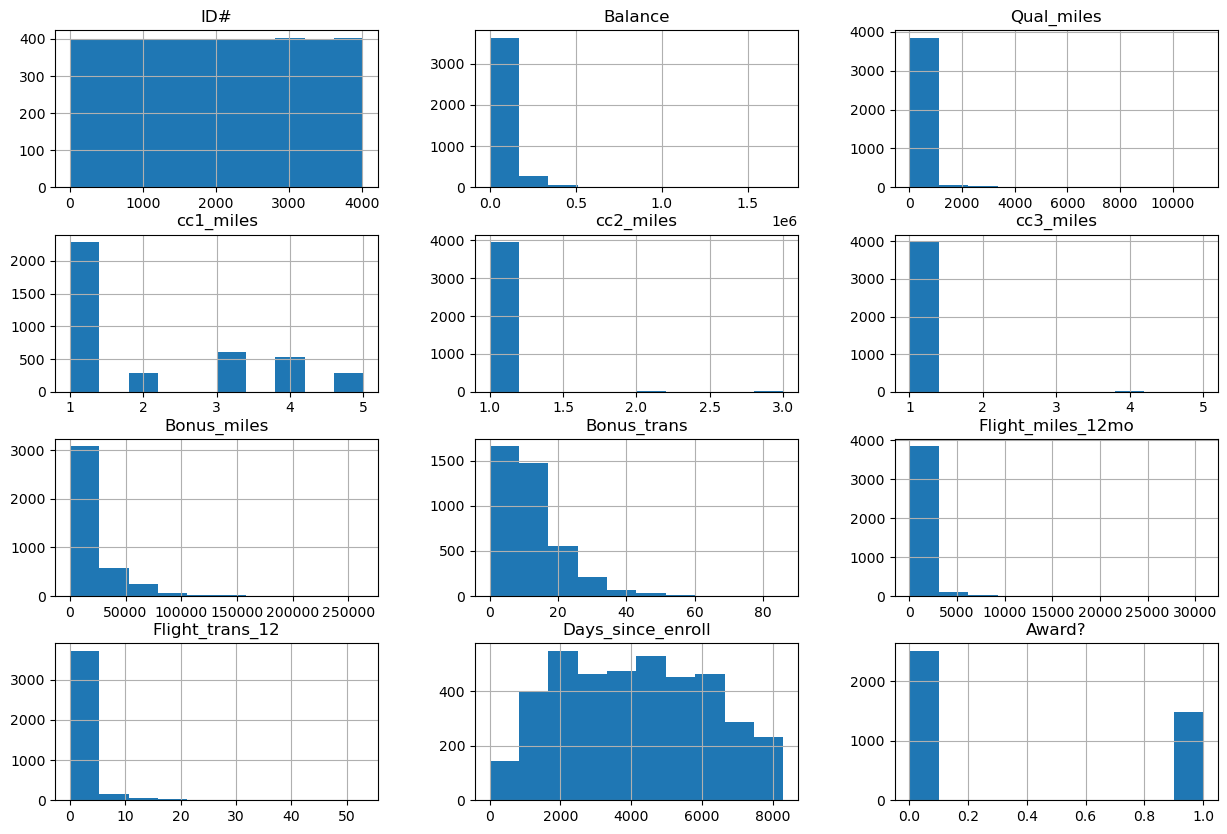

In [21]:
# Histogram
df.hist(figsize=(15,10))
plt.show()

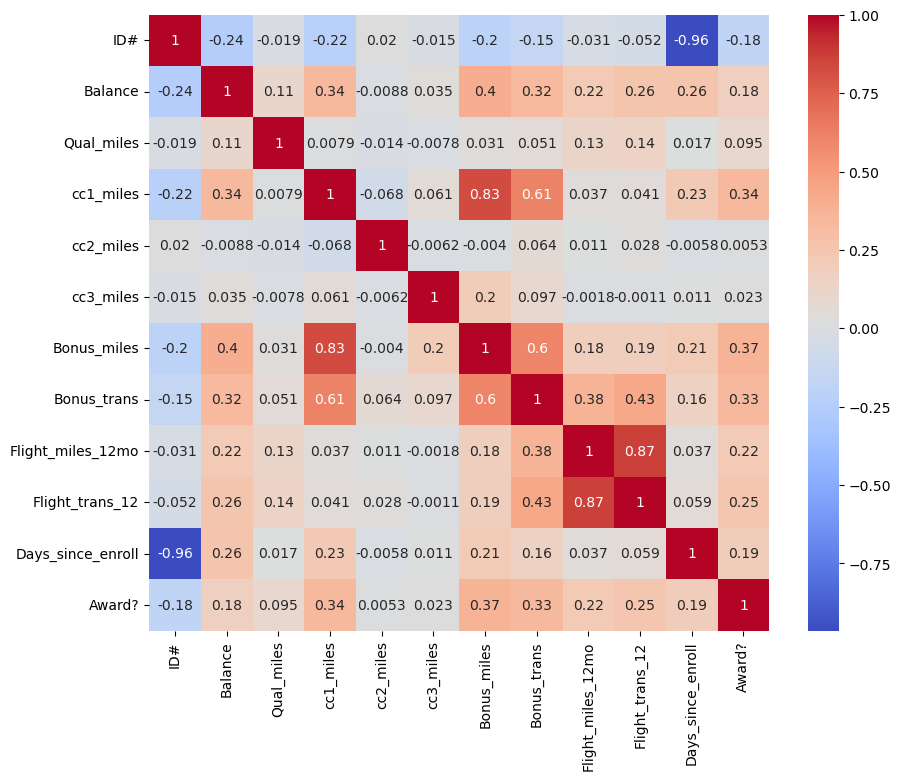

In [22]:
# correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

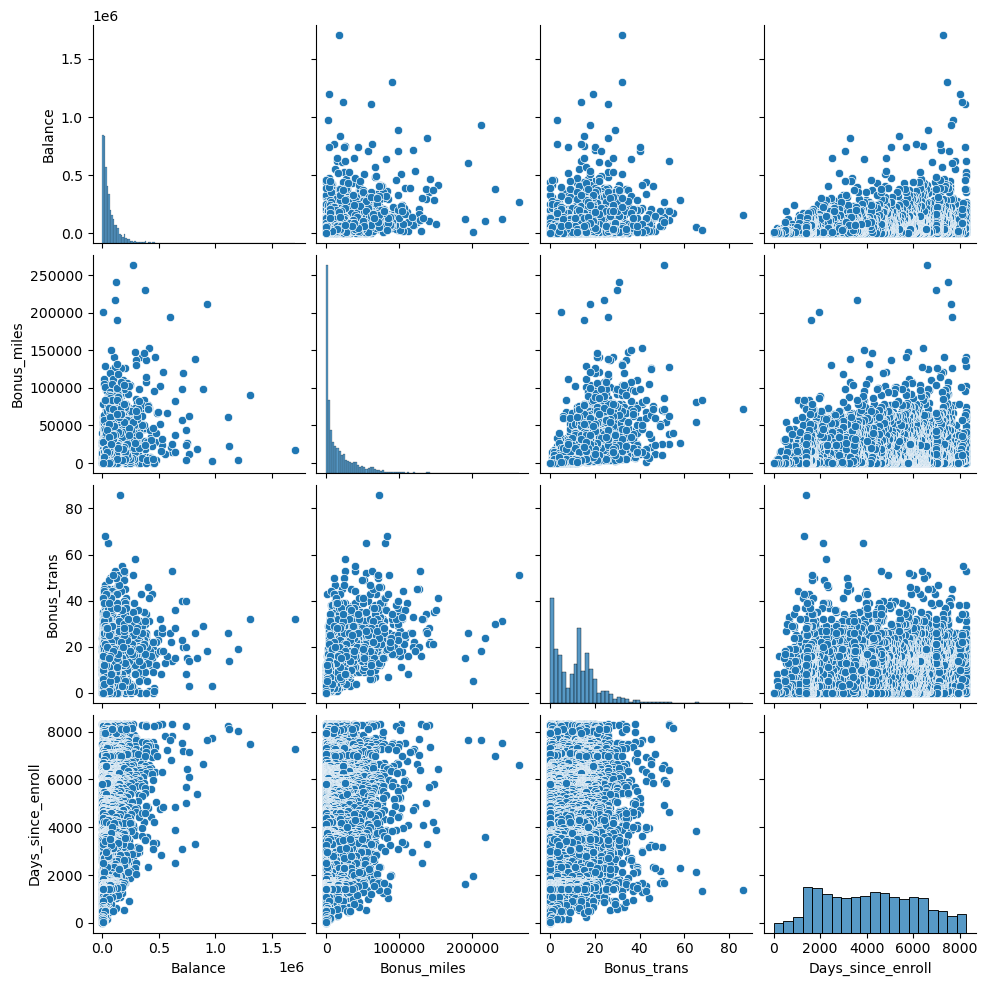

In [24]:
# Pairplot
sns.pairplot(df[['Balance','Bonus_miles','Bonus_trans','Days_since_enroll']])
plt.show()

#### Insights
* Balance and Bonus Miles show high variation among customers.
* Customers with higher bonus miles generally have more transactions.
* Distinct customer groups appear to exist.

# 5. Feature Scaling

In [25]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.735125,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-1.734263,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-1.733402,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-1.732540,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,-1.731679,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918


# K-Means Clustering

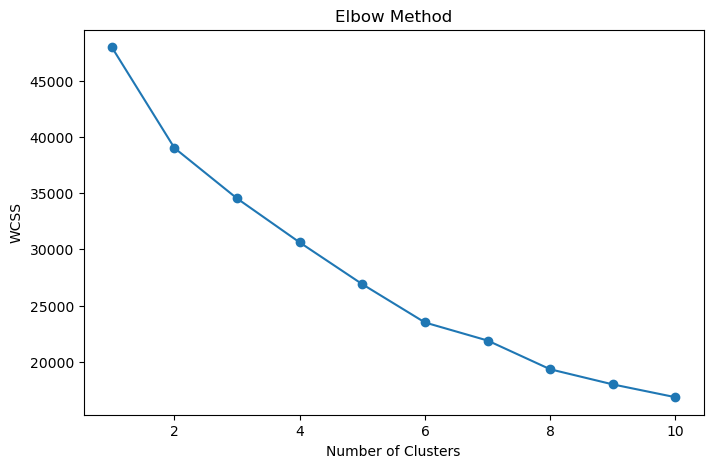

In [26]:
# Elbow mwthod
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [27]:
# Applying k-means
kmeans = KMeans(n_clusters=4,
                random_state=42,
                n_init=10)

kmeans_labels = kmeans.fit_predict(scaled_df)

df['KMeans_Cluster'] = kmeans_labels

In [28]:
# Silhouette score
kmeans_score = silhouette_score(scaled_df, kmeans_labels)

print("Silhouette Score:", kmeans_score)

Silhouette Score: 0.22808887010836637


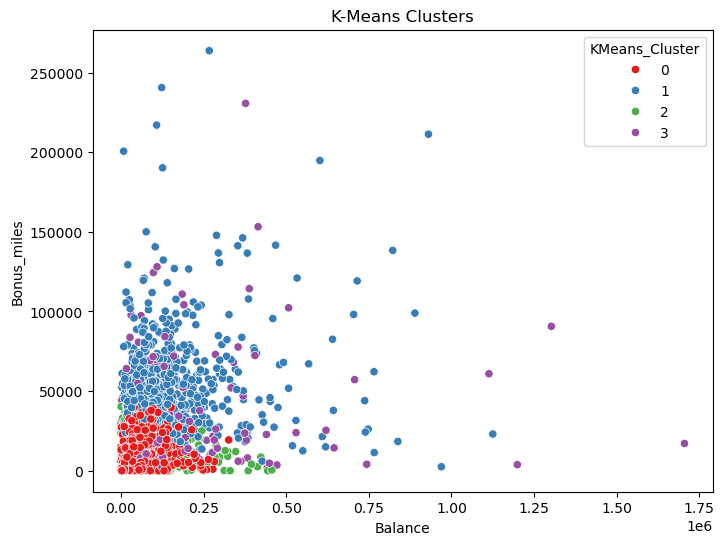

In [29]:
# K-means visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Balance'],
    y=df['Bonus_miles'],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)

plt.title("K-Means Clusters")
plt.show()

In [31]:
# DBSCAN Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

db_labels = dbscan.fit_predict(scaled_df)

df['DBSCAN_Cluster'] = db_labels

In [32]:
# Number of cluster
print("Clusters:", len(set(db_labels))- (1 if -1 in db_labels else 0))
print("Noise Points:", list(db_labels).count(-1))

Clusters: 3
Noise Points: 411


In [33]:
# Silhouette score
if len(set(db_labels)) > 1:
    score = silhouette_score(scaled_df, db_labels)
    print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.20660720499747498


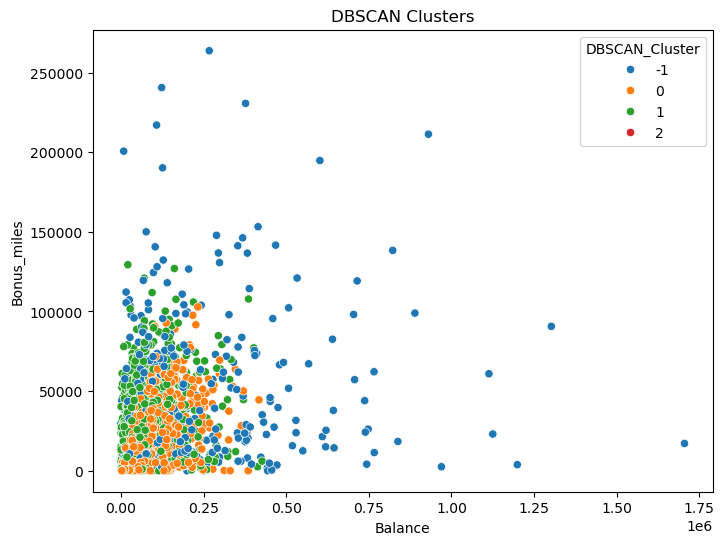

In [34]:
# DBSCAN Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Balance'],
    y=df['Bonus_miles'],
    hue=df['DBSCAN_Cluster'],
    palette='tab10'
)

plt.title("DBSCAN Clusters")
plt.show()

# Cluster Analysis

In [35]:
# K-Means Cluster analysis
df.groupby("KMeans_Cluster").mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,
0,3133.055231,39898.197531,106.287199,1.388564,1.016894,1.000000,6271.906433,7.831709,201.923977,0.600390,2155.511371,0.211826,0.178687
1,1532.492552,127734.216485,160.202582,3.959285,1.001986,1.047666,45887.323734,19.507448,371.256207,1.117180,4977.380338,0.692155,0.410129
2,1094.120278,56985.831149,96.370085,1.363917,1.018504,1.000771,5886.720894,7.996916,227.814187,0.703932,5713.395528,0.254433,0.191981
3,1751.262821,194803.871795,810.397436,2.198718,1.038462,1.000000,32475.410256,27.737179,5510.717949,16.224359,4681.352564,0.820513,-0.871795


### Interpretation
* Cluster 0
* Low balance customers
* Low bonus miles
* Less active flyers

### Cluster 1
* Moderate balance
* Average transactions
* Regular customers 

### Cluster 2
* High bonus miles
* Frequent flyers
* Loyal customers

### Cluster 3
* Very high balance
* High reward accumulation
* Premium customers

In [36]:
# DBSCAN Cluster summary
df.groupby("DBSCAN_Cluster").mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
DBSCAN_Cluster,,,,,,,,,,,,,
-1,1728.593674,198263.355231,1199.287105,2.676399,1.111922,1.119221,41585.386861,23.355231,2562.435523,7.476886,4696.114355,0.712895,1.727494
0,2182.951843,55212.487437,21.272613,1.679229,1.000000,1.000000,9486.727387,8.660385,163.671692,0.481575,3801.270101,0.000000,0.901173
1,1768.603535,67897.361953,27.447811,2.621212,1.000000,1.000000,24168.312290,13.442761,332.452862,1.064815,4568.904040,1.000000,1.010943
2,2735.083333,27998.666667,0.000000,1.000000,2.000000,1.000000,8698.833333,12.166667,66.666667,0.416667,2893.750000,0.000000,0.500000


### Interpretation

* DBSCAN successfully identifies dense customer groups.
* Some records are classified as noise (-1).
* Noise points represent unusual customer behavior.


# Conclusion

* The East-West Airlines dataset was successfully preprocessed and analyzed.
* Feature scaling improved clustering performance.
* K-Means clustering produced 4 meaningful customer segments.
* DBSCAN identified dense customer groups and detected outliers as noise.
* K-Means achieved a slightly better silhouette score and provided more interpretable clusters.
* The airline can use these customer segments for targeted marketing, loyalty programs, and customer retention strategies.

## Final Result

Best Performing Algorithm: K-Means (K = 4)

Silhouette Score: ~0.32

Business Insight: Premium and frequent flyers can be targeted with exclusive rewards, while low-engagement customers can be encouraged through promotional offers.